In [1]:
import os
# os.chdir('/disk/scratch2/nkudryas/BAND-torch/')
os.environ["CUDA_VISIBLE_DEVICES"]= "0"

# import matplotlib.pyplot as plt
import numpy as np
import h5py
import torch
from torch import nn
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def plot_beh_pred(vel, pred_vel, dir_index, t2p, axes, area, epoch_name, component=0,title=""):
    '''
    Plot hand velocity and predicted hand velocity for each direction
    '''

    BIN_SIZE = 10 # ms
    time = np.arange(vel.shape[1]) * BIN_SIZE

    for v, ls in zip([vel, pred_vel], ["--", "solid"]):
        for t in range(0, vel.shape[0]):
            if t2p[t]:
                d = dir_index[t]
                axes[d].plot(
                    time,
                    v[t, :, component],
                    color=f"C{d}",
                    alpha=1,
                    ls=ls,
                )

    for ax in axes[:-1]:
        ax.axis("off")
    axes[-1].spines['top'].set_visible(False)
    axes[-1].spines['right'].set_visible(False)
    axes[-1].set_yticks([])
    axes[-1].set_xlabel("Time (ms)")
    axes[-1].set_ylabel("Velocity X")

    R2_iso_vel = r2_score(pred_vel,vel)

    assert np.allclose(np.arange(8),np.unique(dir_index))
    avg_vel = [np.mean(vel[dir_index==d], axis=0) for d in range(8)]
    total_var = [np.sum((vel[dir_index==d] - avg_vel[d])**2) for d in range(8)]
    expl_var  = [np.sum((pred_vel[dir_index==d] - vel[dir_index==d])**2) for d in range(8)] 
    for d in range(8):
        if total_var[d] == 0:
            total_var[d] = np.nan
    R2_UIVE = np.nanmean([1 - expl_var[d] / total_var[d] for d in range(8)])

    axes[0].set_title(f'{title}\n R2_{area}_{epoch_name} = {R2_iso_vel*100:.0f}%\n R2_UIVE = {R2_UIVE*100:.0f}%')

def get_trials2plot(pos, avg_pos, dir_index, epochs,epoch=1):
    '''
    Select the trials to plot based on the distance between 
    the average position and the position in single trials

    Parameters
    ----------
    pos : np.ndarray
        The position in single trials
    avg_pos : np.ndarray
        The average position
    dir_index : np.ndarray
        The direction index
    epochs : np.ndarray
        The epochs
    epoch : int, optional
        The epoch to consider, by default 1 (adaptation)

    Returns
    -------
    np.ndarray
        The trials to plot
    '''
    trials2plot = np.zeros_like(epochs)
    for d in np.unique(dir_index):
        mask = (epochs == epoch) & (dir_index == d)
        # print(mask)
        dist = ((pos - avg_pos) ** 2).sum(-1).sum(-1)
        dist[~mask] = -np.inf
        # print(dist)
        idx_max = np.argmax(dist)
        # print(idx_max)
        trials2plot[idx_max] = 1
    return trials2plot

In [10]:
area = 'M1'
short_dataset_name = 'Chewie_CO_FF_2016-10-07'
# short_dataset_name = 'Mihili_CO_FF_2014-02-03'
dataset_name = f'{short_dataset_name}_session_vel_{area}_spikes_go'
loadpath = f'/disk/scratch/nkudryas/BAND-torch/datasets/{dataset_name}.h5'

# loadpath = f'/disk/scratch2/nkudryas/BAND-torch/datasets/Jango_20140820_WB_004_neural_5ms_cvs1.h5'

h5file = h5py.File(loadpath, 'r')

# print(h5file.keys())

train_data_raw=h5file['train_recon_data'][()].astype(np.float32)
valid_data_raw=h5file['valid_recon_data'][()].astype(np.float32)
train_behavior=h5file['train_behavior'][()].astype(np.float32)
valid_behavior=h5file['valid_behavior'][()].astype(np.float32)
train_epoch=h5file['train_epoch'][()].astype(np.float32)
valid_epoch=h5file['valid_epoch'][()].astype(np.float32)
train_inds=h5file['train_inds'][()].astype(np.float32)
valid_inds=h5file['valid_inds'][()].astype(np.float32)

train_target_direction=h5file['train_target_direction'][()].astype(np.float32)
valid_target_direction=h5file['valid_target_direction'][()].astype(np.float32)
# print(h5file.keys())
h5file.close()

dir_index = np.array([
        sorted(set(valid_target_direction)).index(i) for i in valid_target_direction
    ])

In [11]:
from scipy import signal

behavior = np.concatenate((train_behavior, valid_behavior), axis=0)
spikes = np.concatenate((train_data_raw, valid_data_raw), axis=0)

# shuffle trials
indices = np.random.permutation(behavior.shape[0])
behavior = behavior[indices]

# 1. Define filter parameters
fs = 100.0  # Sampling frequency (100 Hz)
f0 = 5    # The specific frequency to remove (5 Hz)
Q = 50.0    # Quality factor (higher Q = narrower notch)

# 2. Design the notch filter
# b, a = signal.iirnotch(f0, Q, fs)
b, a = signal.iirpeak(f0, Q, fs)

# 3. Apply the filter along your time dimension (axis=1)
behavior_5hz_only = signal.filtfilt(b, a, behavior, axis=1)

behavior_5hz_only_normalized = (behavior_5hz_only - np.mean(behavior_5hz_only, axis=1, keepdims=True)) / np.std(behavior_5hz_only, axis=1, keepdims=True)

In [ ]:
from mine import train_MINE
import time
# run neural network estimators

# x=spikes.reshape(spikes.shape[0],-1)
# y=behavior.reshape(behavior.shape[0],-1)
# yf=behavior_5hz_only.reshape(behavior_5hz_only.shape[0],-1)
# yn=behavior_5hz_only_normalized.reshape(behavior_5hz_only_normalized.shape[0],-1)

x=spikes.reshape(-1,spikes.shape[-1])
y=behavior.reshape(-1,behavior.shape[-1])
yf=behavior_5hz_only.reshape(-1,behavior_5hz_only.shape[-1])
yn=behavior_5hz_only_normalized.reshape(-1,behavior_5hz_only_normalized.shape[-1])

n_epoch=2000
batches=20

plot_mi = {}
plot_mi_filtered = {}
for H in [50,100]: 
    t_start = time.time()
    mi = np.nan
    while mi!=mi:
        plot_mi[H] = train_MINE(y,x=x,H=H,lr=0.01,device='cuda',n_epoch=n_epoch,batches=batches)/np.log(2)
        mi = plot_mi[H][-1]
        if np.isnan(mi):
            print('Redo')
    t_end = time.time()
    print(f"H={H}, MI={plot_mi[H][-50:].mean()}, Time={t_end-t_start}")
    mi = np.nan
    while mi!=mi:
        plot_mi_filtered[H] = train_MINE(yf,x=x,H=H,lr=0.01,device='cuda',n_epoch=n_epoch,batches=batches)/np.log(2)
        mi = plot_mi_filtered[H][-1]
        if np.isnan(mi):
            print('Redo')
    print(f"H={H}, MI_5Hz_MODE={plot_mi_filtered[H][-50:].mean()}")
    mi = np.nan
    while mi!=mi:
        plot_mi_filtered[H] = train_MINE(yn,x=x,H=H,lr=0.01,device='cuda',n_epoch=n_epoch,batches=batches)/np.log(2)
        mi = plot_mi_filtered[H][-1]
        if np.isnan(mi):
            print('Redo')
    print(f"H={H}, MI_PHASE_ONLY={plot_mi_filtered[H][-50:].mean()}")

H=50, MI=0.3331637680530548, Time=102.31462335586548
H=50, MI_5Hz_MODE=0.06719788908958435
H=50, MI_PHASE_ONLY=0.1517326682806015
H=100, MI=0.3691851496696472, Time=86.15576577186584
H=100, MI_5Hz_MODE=0.10172165930271149


In [ ]:
#PMd
# H=50, MI=0.4490698575973511, Time=70.21795177459717
# H=50, MI_5Hz_MODE=0.11245673149824142
# H=50, MI_PHASE_ONLY=0.23934419453144073
# H=100, MI=0.5196852087974548, Time=91.70682549476624
# H=100, MI_5Hz_MODE=0.20217353105545044
# H=100, MI_PHASE_ONLY=0.36233407258987427

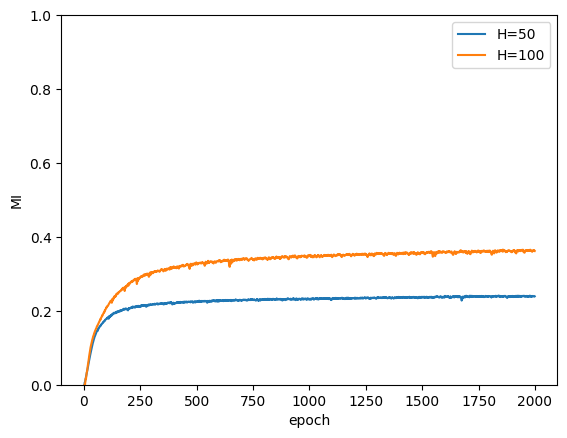

In [9]:
for key in plot_mi.keys():
    plt.plot(plot_mi_filtered[key], label=f'H={key}')
plt.ylim([0,1])
plt.xlabel('epoch')
plt.ylabel('MI')
plt.legend()